# Differential Microstrip Modes (2D Cross-Section)

This notebook builds a boxed differential microstrip cross-section (substrate + air + ground plane + two PEC strips), solves eigenmodes, and plots the first fields.

In [1]:
from palacetoolkit.mode_solver import WaveguideModeSolver
from palacetoolkit.utils import view_fe_mesh_2d, view_fields_2d, write_and_finalize_gmsh
from palacetoolkit.viz import view_mesh

import gmsh
import numpy as np

In [2]:
def make_differential_microstrip_mesh(
    box_w=8.0,
    h_sub=1.0,
    h_air=3.0,
    strip_w=0.8,
    strip_gap=0.5,
    strip_t=0.06,
    lc_bulk=0.18,
    lc_strip=0.05,
    filename=None,
):
    gmsh.initialize()
    gmsh.option.setNumber("General.Verbosity", 0)
    gmsh.model.add("differential_microstrip_modes")

    sub = gmsh.model.occ.addRectangle(-box_w / 2, -h_sub, 0, box_w, h_sub)
    air = gmsh.model.occ.addRectangle(-box_w / 2, 0.0, 0, box_w, h_air)

    x1 = -(strip_gap / 2 + strip_w)
    x2 = strip_gap / 2
    strip_p = gmsh.model.occ.addRectangle(x1, 0.0, 0, strip_w, strip_t)
    strip_n = gmsh.model.occ.addRectangle(x2, 0.0, 0, strip_w, strip_t)

    _, outmap = gmsh.model.occ.fragment([(2, sub), (2, air), (2, strip_p), (2, strip_n)], [])
    gmsh.model.occ.remove(list(outmap[2]) + list(outmap[3]), recursive=True)
    gmsh.model.occ.synchronize()

    all_surfs = [t for _, t in gmsh.model.getEntities(2)]
    substrate_surfs = []
    air_surfs = []
    for tag in all_surfs:
        _, cy, _ = gmsh.model.occ.getCenterOfMass(2, tag)
        if cy < -1e-9:
            substrate_surfs.append(tag)
        else:
            air_surfs.append(tag)

    gmsh.model.addPhysicalGroup(2, substrate_surfs, tag=1, name="substrate")
    gmsh.model.addPhysicalGroup(2, air_surfs, tag=2, name="air")

    bnd = gmsh.model.getBoundary([(2, t) for t in substrate_surfs + air_surfs], oriented=False, combined=False)
    edge_tags = sorted({abs(t) for _, t in bnd})

    strip_p_edges = []
    strip_n_edges = []
    ground_edges = []
    open_edges = []

    c1 = x1 + strip_w / 2
    c2 = x2 + strip_w / 2
    for et in edge_tags:
        ex, ey, _ = gmsh.model.occ.getCenterOfMass(1, et)
        on_strip_y = (-1e-6 <= ey <= strip_t + 1e-6)

        if on_strip_y and abs(ex - c1) <= strip_w / 2 + 1e-6:
            strip_p_edges.append(et)
        elif on_strip_y and abs(ex - c2) <= strip_w / 2 + 1e-6:
            strip_n_edges.append(et)
        elif abs(ey + h_sub) <= 1e-6:
            ground_edges.append(et)
        else:
            open_edges.append(et)

    if ground_edges:
        gmsh.model.addPhysicalGroup(1, ground_edges, tag=1, name="ground_plane")
    if strip_p_edges:
        gmsh.model.addPhysicalGroup(1, strip_p_edges, tag=2, name="strip_p")
    if strip_n_edges:
        gmsh.model.addPhysicalGroup(1, strip_n_edges, tag=3, name="strip_n")
    if open_edges:
        gmsh.model.addPhysicalGroup(1, open_edges, tag=4, name="open_boundary")

    for _, ptag in gmsh.model.getEntities(0):
        x, y, _ = gmsh.model.getValue(0, ptag, [])
        near_pair = (abs(x) <= (strip_gap / 2 + strip_w + 0.8) and -0.1 <= y <= strip_t + 0.5)
        gmsh.model.mesh.setSize([(0, ptag)], lc_strip if near_pair else lc_bulk)

    gmsh.model.mesh.generate(2)
    return write_and_finalize_gmsh(filename, prefix="wg_diffms_")

In [3]:
eps_sub = 4.0
eps_air = 1.0
mu_r = 1.0
omega = 16.0

Loading mesh file: /tmp/wg_diffms_s87r7l25.msh
Groups to render transparent: ['air_none', 'air_plastic_enclosure']

Mesh loaded successfully with 2 cell blocks
Found 5826 triangles total
Physical group tags in mesh: {1: 'substrate', 2: 'air'}



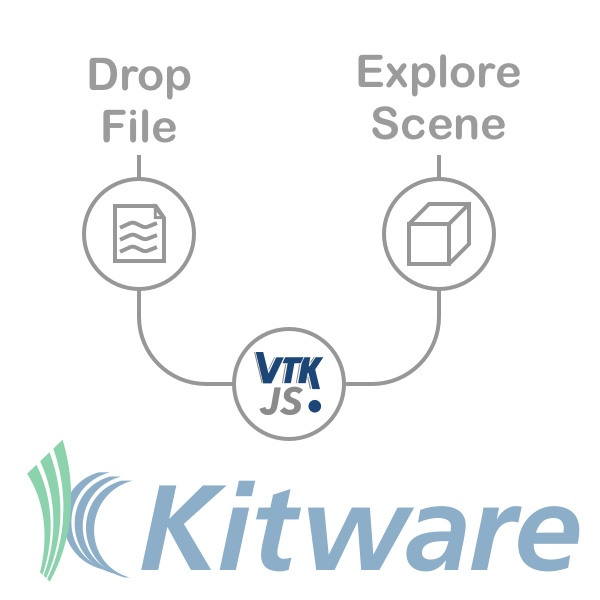

  FE spaces: ND dofs = 29338, H1 dofs = 11859, total = 41197
  Essential DOFs: ND = 234, H1 = 235, total = 469


  Solving eigenvalue problem (omega = 16, sigma = -1126.4, size = 41197)...


  Found 8 modes:
    Mode 1: kn = +3.19729249e+01 -0.00000000e+00j <-- selected
    Mode 2: kn = +3.19611499e+01 -0.00000000e+00j
    Mode 3: kn = +3.19568982e+01 -0.00000000e+00j
    Mode 4: kn = +3.19474805e+01 -0.00000000e+00j
    Mode 5: kn = +3.19262270e+01 -0.00000000e+00j
    Mode 6: kn = +3.19115007e+01 -0.00000000e+00j
    Mode 7: kn = +3.18770498e+01 -0.00000000e+00j
    Mode 8: kn = +3.18537901e+01 -0.00000000e+00j
Computed differential microstrip modes:
  Mode  1: kn=+31.972925 -0.000000j
  Mode  2: kn=+31.961150 -0.000000j
  Mode  3: kn=+31.956898 -0.000000j
  Mode  4: kn=+31.947481 -0.000000j
  Mode  5: kn=+31.926227 -0.000000j
  Mode  6: kn=+31.911501 -0.000000j
  Mode  7: kn=+31.877050 -0.000000j
  Mode  8: kn=+31.853790 -0.000000j


In [4]:
mesh_file = make_differential_microstrip_mesh(
    box_w=8.0,
    h_sub=1.0,
    h_air=3.0,
    strip_w=0.8,
    strip_gap=0.5,
    strip_t=0.06,
)
view_mesh(mesh_file)

mu_inv = {1: 1.0 / mu_r, 2: 1.0 / mu_r}
eps = {1: eps_sub, 2: eps_air}

# Ground and both strips are PEC; top/sides remain non-PEC.
pec_bdr = [1, 2, 3]

solver = WaveguideModeSolver(mesh_file, order=2, mu_inv=mu_inv, eps=eps, pec_bdr=pec_bdr)
results = solver.solve(omega, num_modes=8, mode_idx=1)

print("Computed differential microstrip modes:")
for i, kn in enumerate(results["kn"], start=1):
    print(f"  Mode {i:2d}: kn={kn.real:+10.6f}{kn.imag:+10.6f}j")

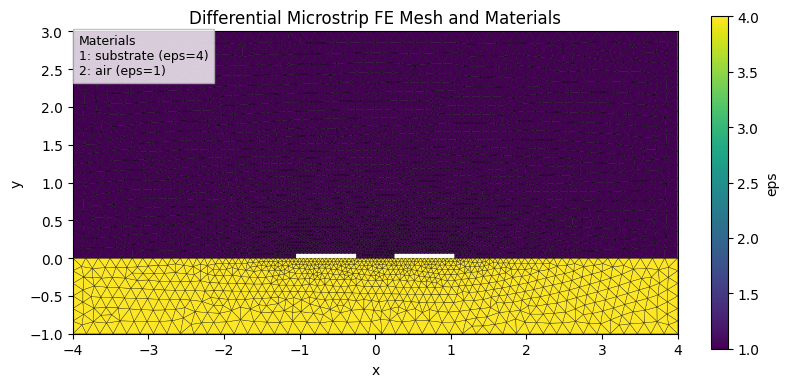

In [5]:
view_fe_mesh_2d(
    mesh_file=mesh_file,
    eps=eps,
    title="Differential Microstrip FE Mesh and Materials",
    show_edges=True,
)




MFEM Warning: 16 points were not found
 ... in function: virtual int mfem::Mesh::FindPoints(mfem::DenseMatrix&, mfem::Array<int>&, mfem::Array<mfem::IntegrationPoint>&, bool, mfem::InverseElementTransformation*)
 ... in file: /__w/PyMFEM/PyMFEM/PyMFEM/external/mfem/mesh/mesh.cpp:13515





MFEM Warning: 16 points were not found
 ... in function: virtual int mfem::Mesh::FindPoints(mfem::DenseMatrix&, mfem::Array<int>&, mfem::Array<mfem::IntegrationPoint>&, bool, mfem::InverseElementTransformation*)
 ... in file: /__w/PyMFEM/PyMFEM/PyMFEM/external/mfem/mesh/mesh.cpp:13515





MFEM Warning: 16 points were not found
 ... in function: virtual int mfem::Mesh::FindPoints(mfem::DenseMatrix&, mfem::Array<int>&, mfem::Array<mfem::IntegrationPoint>&, bool, mfem::InverseElementTransformation*)
 ... in file: /__w/PyMFEM/PyMFEM/PyMFEM/external/mfem/mesh/mesh.cpp:13515



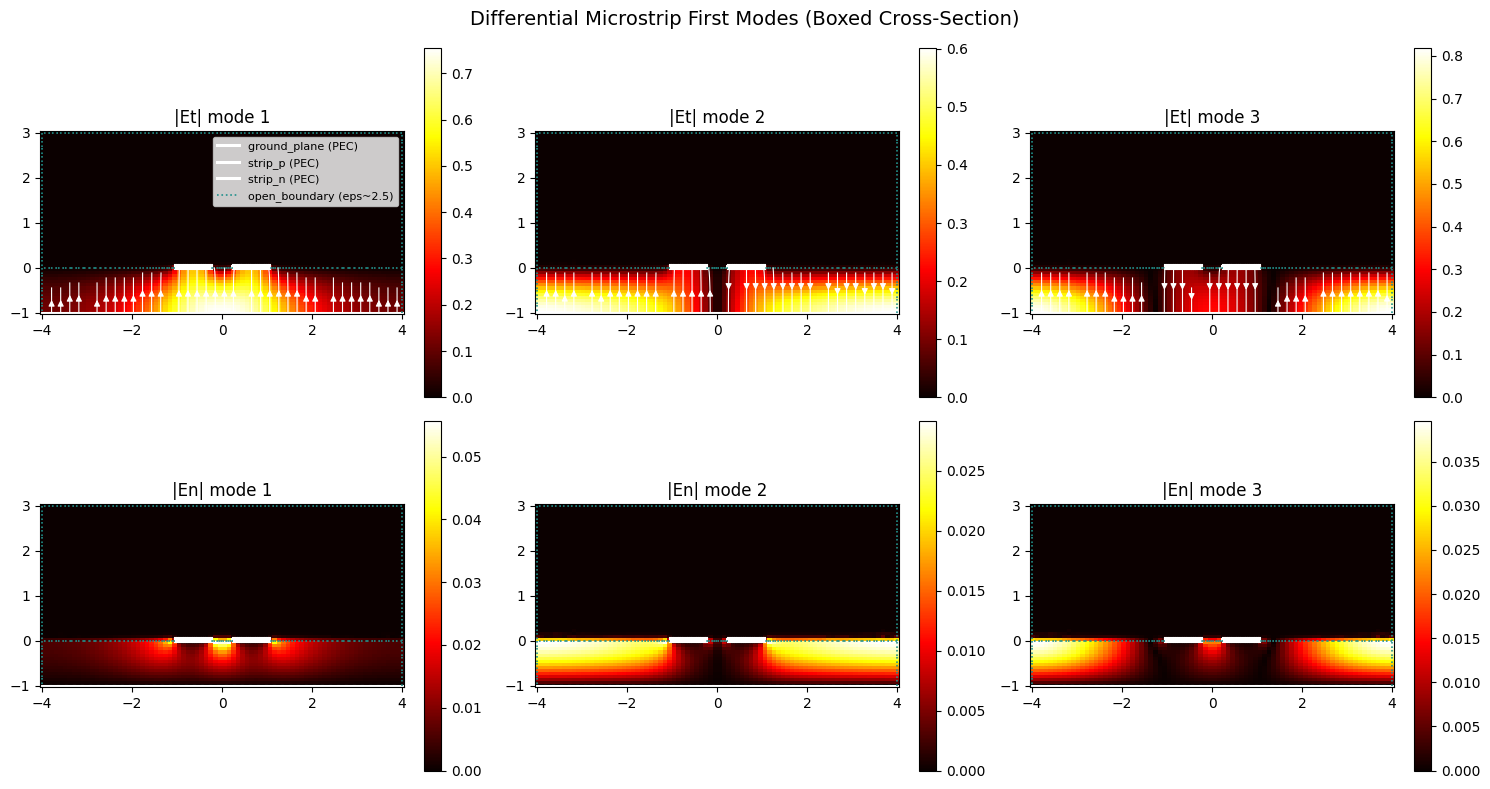

In [6]:
view_fields_2d(
    solver=solver,
    results=results,
    mesh_file=mesh_file,
    eps=eps,
    pec_bdr=pec_bdr,
    include_streamplot=True,
    streamplot_density=1.2,
    streamplot_show_arrows=True,
    streamplot_normalize=True,
    streamplot_seed_from_field=True,
    streamplot_seed_frac=0.1,
    streamplot_seed_stride=2,
    streamplot_mask_weak=True,
    streamplot_min_frac=0.1,
    num_modes=3,
    nx=80,
    ny=60,
    cmap="hot",
    title="Differential Microstrip First Modes (Boxed Cross-Section)",
)